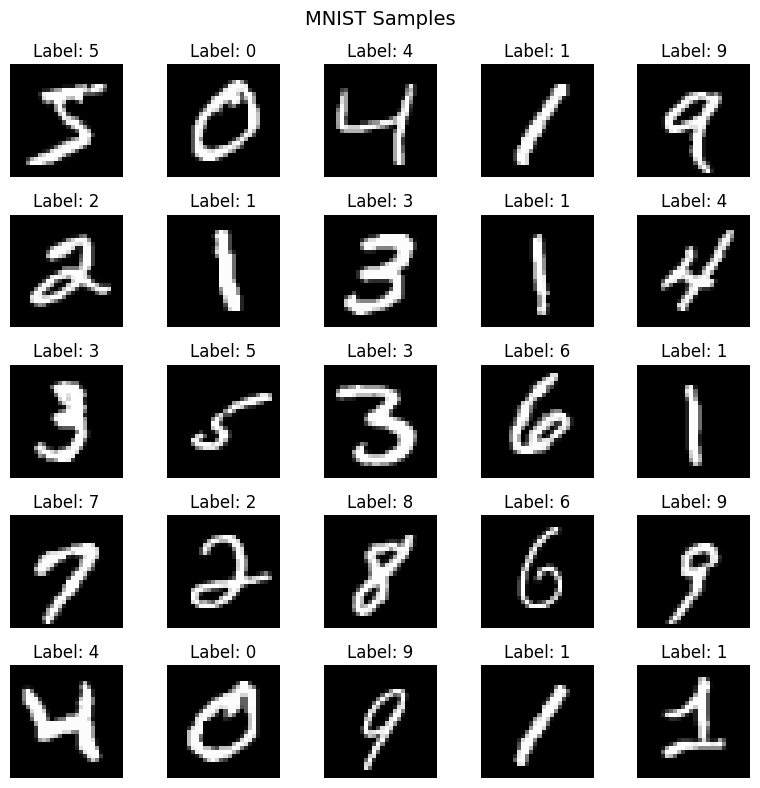

60000

In [35]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Download MNIST dataset
transform = transforms.ToTensor()
train_mnist = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_mnist = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Show a grid of 25 sample images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):

    img, label = train_mnist[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

len(train_mnist)



In [36]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_mnist, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_mnist, batch_size=batch_size, shuffle=False
)

In [37]:
images, label = next(iter(train_loader))
print(images.shape)

torch.Size([64, 1, 28, 28])


In [38]:
print(labels.dtype, labels.min().item(), labels.max().item())

torch.int64 0 9


In [39]:
class FFNN(torch.nn.Module):
    def __init__(self):
        super(FFNN, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 200)  # fully connected layer 1 ### how did you decide the size of the image here?
        self.fc2 = torch.nn.Linear(200, 64)
        self.fc3 = torch.nn.Linear(64, 10)

    # 784 -> 128 -> 64 -> 10
    # input -> hidden1 -> hidden2 -> output

    def forward(self, x):
        l1_input = self.fc1(x.view(-1, 28 * 28))
        l1_output = torch.relu(l1_input)
        l2_input = self.fc2(l1_output)
        l2_output = torch.relu(l2_input)
        logits = self.fc3(l2_output)
        return logits

Here we have defined the model structure in a standard way. but there is another way to define the model architecture using sequential function. Something like the below 

In [ ]:
#somthing like this 
# self.network = torch.nn.Sequential(
#     torch.nn.Linear(784,200),
#     torch.nn.ReLU(),
#     torch.nn.Linear(200,64),
#     torch.nn.ReLU(),
#     torch.nn.Linear(64,10)
# )
# def forward(self,x):
#     x = x.view(-1,784)
#     return self.network(x)

In [40]:
epochs = 3
learning_rate = 0.005

In [41]:
model = FFNN()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [42]:
train_loss_history = []          # batch-level loss
train_epoch_losses = []          # epoch-level average loss
train_epoch_accuracies = []      # epoch-level accuracy
test_epoch_accuracies = []       # epoch-level test accuracy
test_epoch_losses = []           # epoch-level test loss

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for b_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        outputs = model(images)                  # raw logits
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # store batch loss
        train_loss_history.append(loss.item())

        # accumulate epoch loss
        running_loss += loss.item()

        # compute training accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (b_idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], "
                f"Step [{b_idx + 1}/{len(train_loader)}], "
                f"Loss: {loss.item():.4f}"
            )

    # epoch-level training metrics
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct / total

    train_epoch_losses.append(epoch_train_loss)
    train_epoch_accuracies.append(epoch_train_acc)

    # evaluate on test set after each epoch
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    epoch_test_loss = test_loss / len(test_loader)
    epoch_test_acc = test_correct / test_total

    test_epoch_losses.append(epoch_test_loss)
    test_epoch_accuracies.append(epoch_test_acc)

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f}"
    )

Epoch [1/3], Step [100/938], Loss: 0.3698
Epoch [1/3], Step [200/938], Loss: 0.1308
Epoch [1/3], Step [300/938], Loss: 0.1668
Epoch [1/3], Step [400/938], Loss: 0.1239
Epoch [1/3], Step [500/938], Loss: 0.2022
Epoch [1/3], Step [600/938], Loss: 0.0849
Epoch [1/3], Step [700/938], Loss: 0.0512
Epoch [1/3], Step [800/938], Loss: 0.1354
Epoch [1/3], Step [900/938], Loss: 0.1161
Epoch [1/3] | Train Loss: 0.2259 | Train Acc: 0.9322 | Test Loss: 0.1355 | Test Acc: 0.9569
Epoch [2/3], Step [100/938], Loss: 0.1405
Epoch [2/3], Step [200/938], Loss: 0.0271
Epoch [2/3], Step [300/938], Loss: 0.4217
Epoch [2/3], Step [400/938], Loss: 0.0728
Epoch [2/3], Step [500/938], Loss: 0.0255
Epoch [2/3], Step [600/938], Loss: 0.0642
Epoch [2/3], Step [700/938], Loss: 0.1610
Epoch [2/3], Step [800/938], Loss: 0.2574
Epoch [2/3], Step [900/938], Loss: 0.0581
Epoch [2/3] | Train Loss: 0.1047 | Train Acc: 0.9678 | Test Loss: 0.1039 | Test Acc: 0.9709
Epoch [3/3], Step [100/938], Loss: 0.0253
Epoch [3/3], Step 

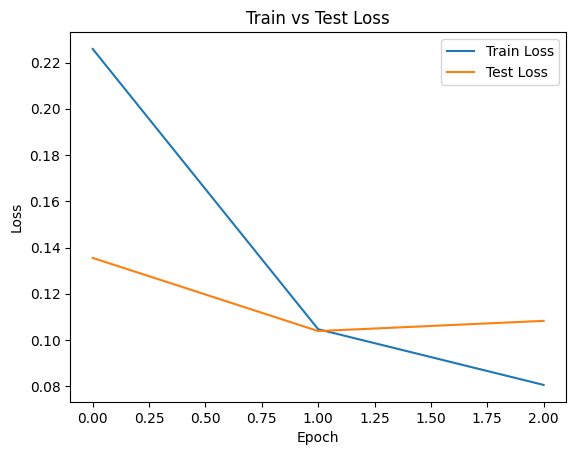

In [43]:
import matplotlib.pyplot as plt

plt.plot(train_epoch_losses, label="Train Loss")
plt.plot(test_epoch_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.show()

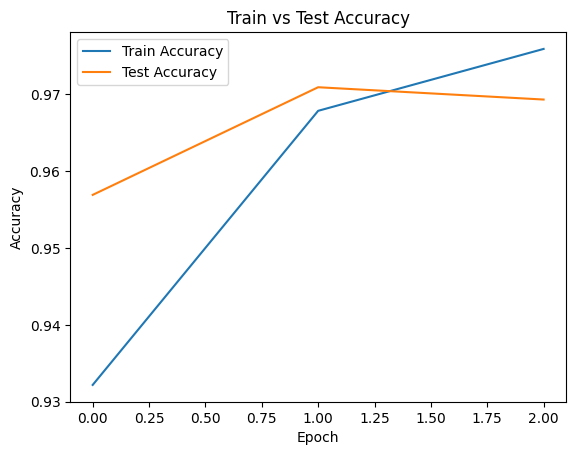

In [44]:
plt.plot(train_epoch_accuracies, label="Train Accuracy")
plt.plot(test_epoch_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()

In [45]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Accuracy: 0.9693


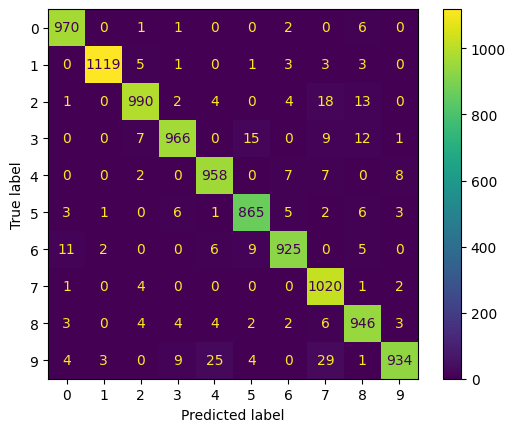

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# loss_history = []

# for epoch in range(epochs):
#     for b_idx, (images, labels) in enumerate(train_loader):
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         loss_history.append(loss.item())   # store loss

#         if (b_idx + 1) % 100 == 0:
#             print(
#                 f"Epoch [{epoch + 1}/{epochs}], Step [{b_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}"
#             )

Epoch [1/3], Step [100/938], Loss: 0.1952
Epoch [1/3], Step [200/938], Loss: 0.1747
Epoch [1/3], Step [300/938], Loss: 0.1654
Epoch [1/3], Step [400/938], Loss: 0.1743
Epoch [1/3], Step [500/938], Loss: 0.0727
Epoch [1/3], Step [600/938], Loss: 0.1284
Epoch [1/3], Step [700/938], Loss: 0.1385
Epoch [1/3], Step [800/938], Loss: 0.1151
Epoch [1/3], Step [900/938], Loss: 0.1621
Epoch [2/3], Step [100/938], Loss: 0.0235
Epoch [2/3], Step [200/938], Loss: 0.1854
Epoch [2/3], Step [300/938], Loss: 0.0220
Epoch [2/3], Step [400/938], Loss: 0.0867
Epoch [2/3], Step [500/938], Loss: 0.1470
Epoch [2/3], Step [600/938], Loss: 0.0887
Epoch [2/3], Step [700/938], Loss: 0.0401
Epoch [2/3], Step [800/938], Loss: 0.0645
Epoch [2/3], Step [900/938], Loss: 0.1831
Epoch [3/3], Step [100/938], Loss: 0.0303
Epoch [3/3], Step [200/938], Loss: 0.0361
Epoch [3/3], Step [300/938], Loss: 0.1334
Epoch [3/3], Step [400/938], Loss: 0.0670
Epoch [3/3], Step [500/938], Loss: 0.1124
Epoch [3/3], Step [600/938], Loss:

when you look at training logs like this, you should train your brain to answer three questions:
1️⃣ Is the model learning?
2️⃣ How fast is it learning?
3️⃣ Is the architecture too small or too big?

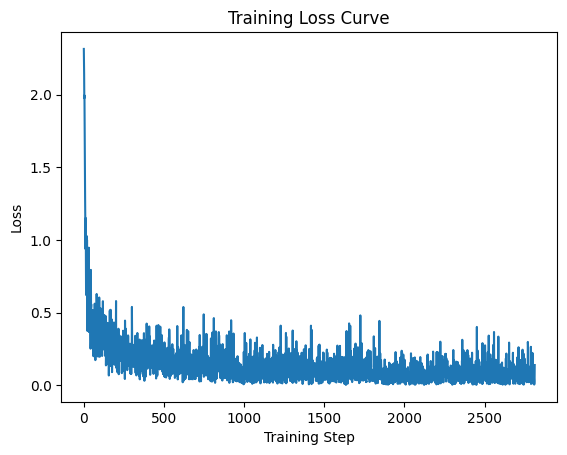

In [33]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [34]:
for epoch in range(epochs):
    for b_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if (b_idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], Step [{b_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}"
            )
print(images.shape)

Epoch [1/3], Step [100/938], Loss: 0.0654
Epoch [1/3], Step [200/938], Loss: 0.0376
Epoch [1/3], Step [300/938], Loss: 0.0420
Epoch [1/3], Step [400/938], Loss: 0.0712
Epoch [1/3], Step [500/938], Loss: 0.0706
Epoch [1/3], Step [600/938], Loss: 0.3504
Epoch [1/3], Step [700/938], Loss: 0.0653
Epoch [1/3], Step [800/938], Loss: 0.0266
Epoch [1/3], Step [900/938], Loss: 0.0405
Epoch [2/3], Step [100/938], Loss: 0.0390
Epoch [2/3], Step [200/938], Loss: 0.0946
Epoch [2/3], Step [300/938], Loss: 0.3413
Epoch [2/3], Step [400/938], Loss: 0.0447
Epoch [2/3], Step [500/938], Loss: 0.0078
Epoch [2/3], Step [600/938], Loss: 0.0280
Epoch [2/3], Step [700/938], Loss: 0.0676
Epoch [2/3], Step [800/938], Loss: 0.1721
Epoch [2/3], Step [900/938], Loss: 0.0342
Epoch [3/3], Step [100/938], Loss: 0.0534
Epoch [3/3], Step [200/938], Loss: 0.0319
Epoch [3/3], Step [300/938], Loss: 0.0349
Epoch [3/3], Step [400/938], Loss: 0.0100
Epoch [3/3], Step [500/938], Loss: 0.0015
Epoch [3/3], Step [600/938], Loss:

i have reduced the size of the layers in the nn architecture to observe, if the model is reducing the error or not. In my observation, reducing the layer size, didn't reduce the error. 